## 8.2 경제물리학에서의 양자 확률 진폭과 파동함수

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# 경제 지표를 나타내는 파라미터
theta1 = np.pi / 3   # 예: 시장 변동성
theta2 = np.pi / 4   # 예: 금리
theta3 = np.pi / 6   # 예: 주가

In [3]:
# 3큐비트 양자회로 생성
qc = QuantumCircuit(3)

In [4]:
# 파동함수를 모사하는 매개변수 게이트 적용
qc.ry(theta1, 0)  # 시장 변동성
qc.ry(theta2, 1)  # 금리
qc.ry(theta3, 2)  # 주가

In [5]:
# 경제 지표 간 상관을 도입하는 제어-X 게이트
qc.cx(0, 1)
qc.cx(1, 2)

In [6]:
# 회로 출력
print(qc)

     ┌─────────┐          
q_0: ┤ Ry(π/3) ├──■───────
     ├─────────┤┌─┴─┐     
q_1: ┤ Ry(π/4) ├┤ X ├──■──
     ├─────────┤└───┘┌─┴─┐
q_2: ┤ Ry(π/6) ├─────┤ X ├
     └─────────┘     └───┘


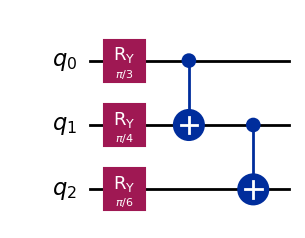

In [7]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [8]:
# 양자 상태 시뮬레이션
simulator = AerSimulator()
qc.save_statevector()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

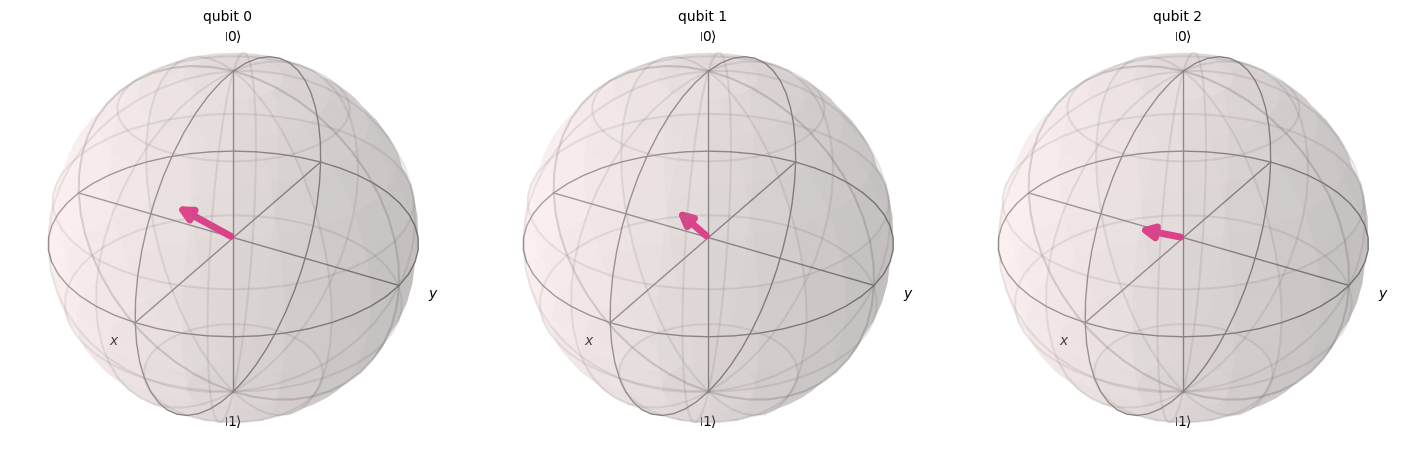

In [9]:
# 상태벡터 획득 후 블로흐 구 그리기
statevector = result.get_statevector()
plot_bloch_multivector(statevector).show()

In [10]:
# 큐비트 측정
qc.measure_all()

In [11]:
# 측정 시뮬레이션
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()
counts = result.get_counts()

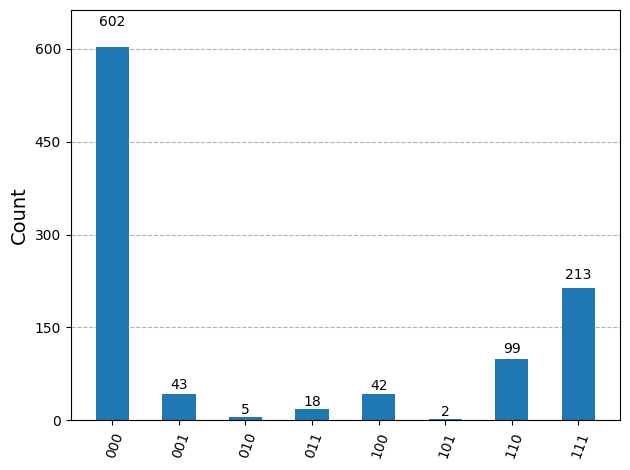

In [12]:
# 결과를 히스토그램으로 그리기
plot_histogram(counts).show()